**WEEK-1**

In [1]:
import pandas as pd
df = pd.read_csv("Indian_Kids_Screen_Time.csv")


In [2]:
df.head()
df.info()
df.describe()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


(9712, 8)

In [3]:
df.isnull().sum()


,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,3218
Urban_or_Rural,0


In [4]:
df['Health_Impacts'] = df['Health_Impacts'].fillna("Unknown")


In [5]:
df.isnull().sum()


,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0


In [6]:
df.duplicated().sum()


np.int64(44)

**Univariate analysis**


Text(0.5, 1.0, 'Urban vs Rural')

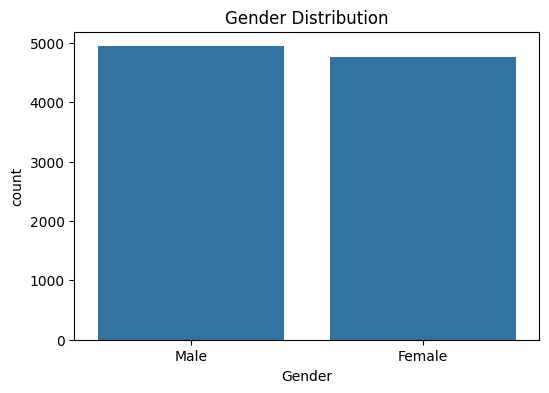

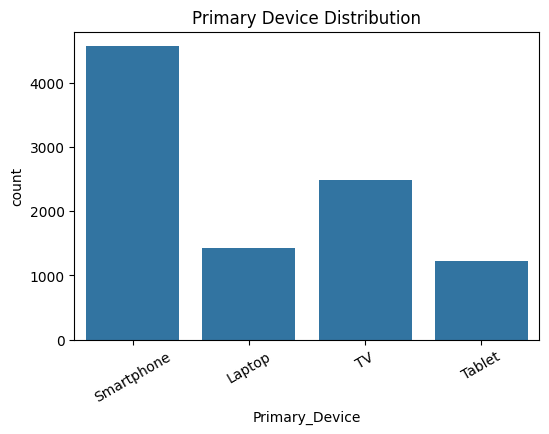

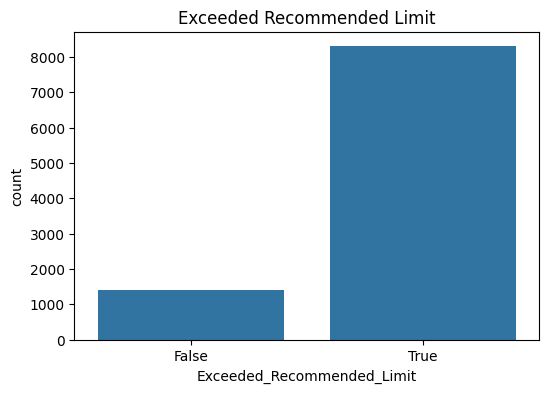

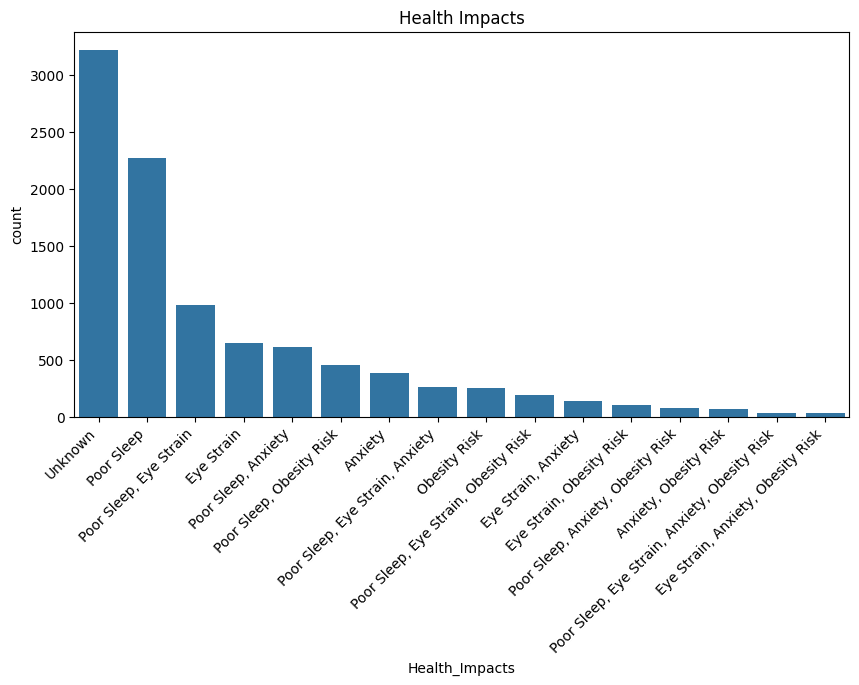

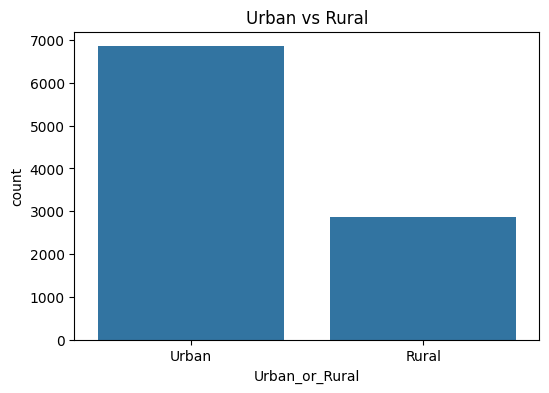

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")

plt.figure(figsize=(6,4))
sns.countplot(x='Primary_Device', data=df)
plt.title("Primary Device Distribution")
plt.xticks(rotation=30)

plt.figure(figsize=(6,4))
sns.countplot(x='Exceeded_Recommended_Limit', data=df)
plt.title("Exceeded Recommended Limit")

plt.figure(figsize=(10,5))
sns.countplot(x='Health_Impacts', data=df, order=df['Health_Impacts'].value_counts().index)
plt.title("Health Impacts")
plt.xticks(rotation=45, ha='right')

plt.figure(figsize=(6,4))
sns.countplot(x='Urban_or_Rural', data=df)
plt.title("Urban vs Rural")


**Bivariate analysis**

Text(0.5, 1.0, 'Correlation Heatmap')

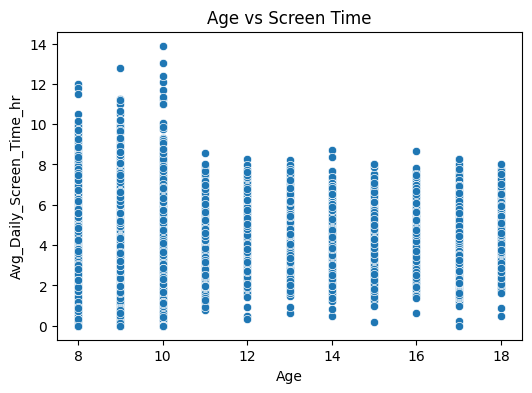

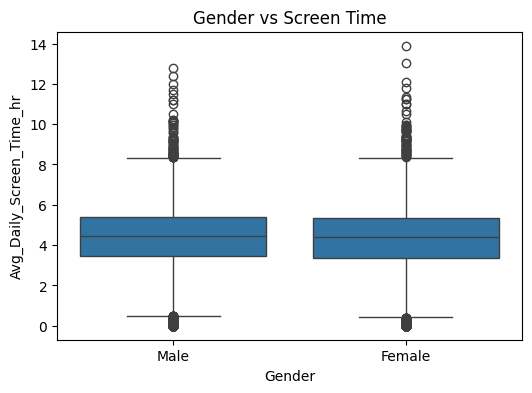

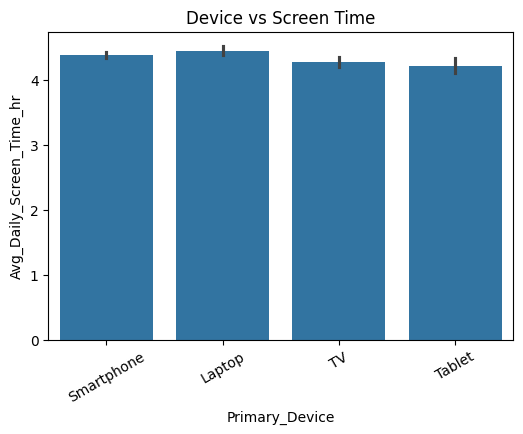

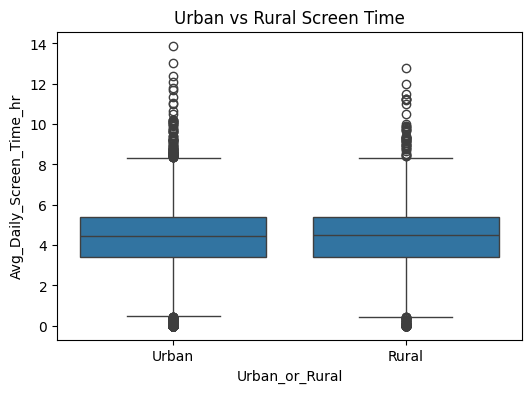

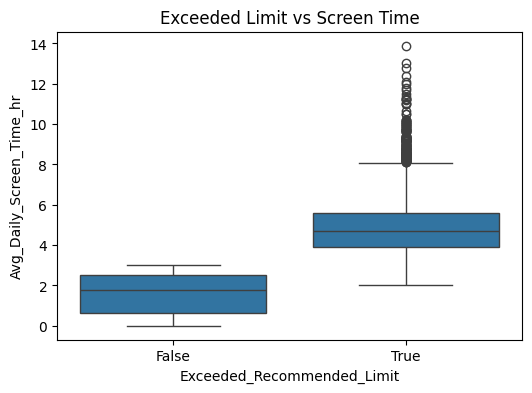

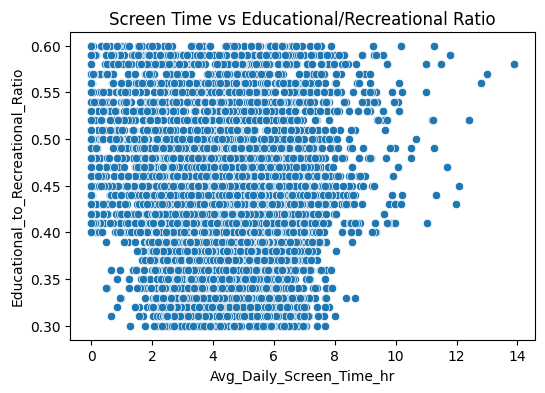

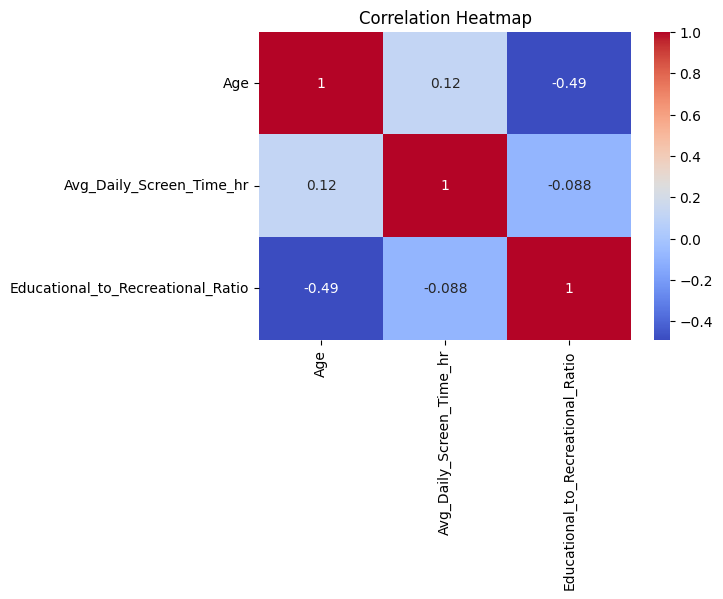

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Age vs Screen Time")

plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Gender vs Screen Time")

plt.figure(figsize=(6,4))
sns.barplot(x='Primary_Device', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Device vs Screen Time")
plt.xticks(rotation=30)

plt.figure(figsize=(6,4))
sns.boxplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Urban vs Rural Screen Time")

plt.figure(figsize=(6,4))
sns.boxplot(x='Exceeded_Recommended_Limit', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Exceeded Limit vs Screen Time")

plt.figure(figsize=(6,4))
sns.scatterplot(x='Avg_Daily_Screen_Time_hr', y='Educational_to_Recreational_Ratio', data=df)
plt.title("Screen Time vs Educational/Recreational Ratio")

plt.figure(figsize=(6,4))
sns.heatmap(df[['Age','Avg_Daily_Screen_Time_hr','Educational_to_Recreational_Ratio']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")


**Multivariate analysis**

Text(0.5, 1.0, 'Screen Time by Urban/Rural & Exceeded Limit')

<Figure size 700x500 with 0 Axes>

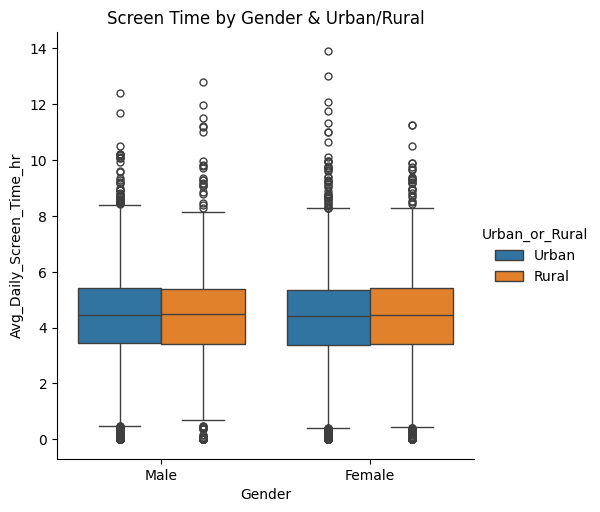

<Figure size 700x500 with 0 Axes>

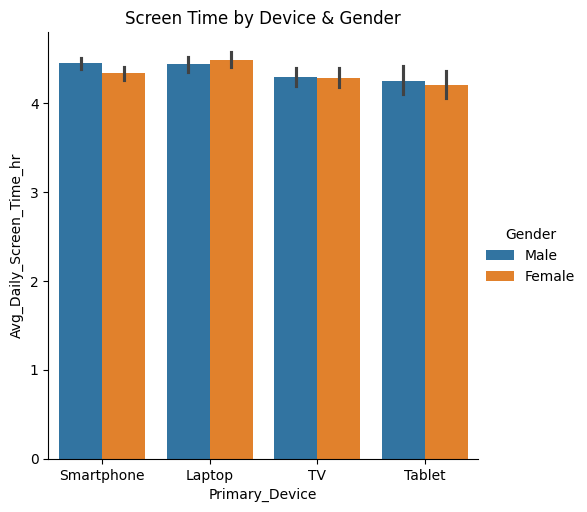

<Figure size 700x500 with 0 Axes>

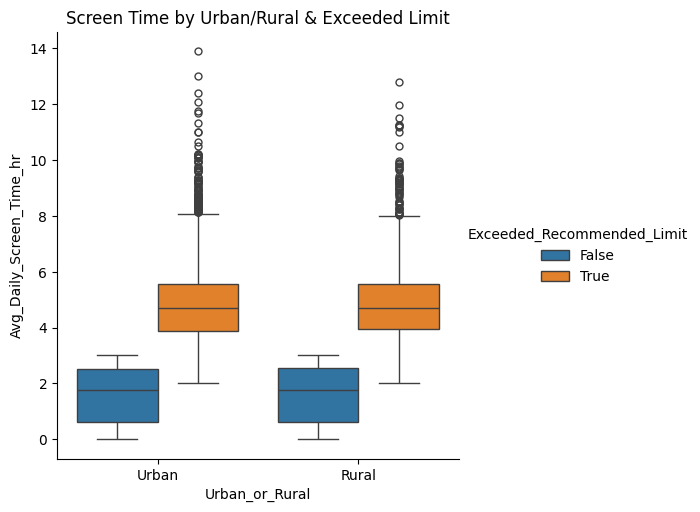

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.catplot(x="Gender", y="Avg_Daily_Screen_Time_hr", hue="Urban_or_Rural", kind="box", data=df)
plt.title("Screen Time by Gender & Urban/Rural")

plt.figure(figsize=(7,5))
sns.catplot(x="Primary_Device", y="Avg_Daily_Screen_Time_hr", hue="Gender", kind="bar", data=df)
plt.title("Screen Time by Device & Gender")

plt.figure(figsize=(7,5))
sns.catplot(x="Urban_or_Rural", y="Avg_Daily_Screen_Time_hr", hue="Exceeded_Recommended_Limit", kind="box", data=df)
plt.title("Screen Time by Urban/Rural & Exceeded Limit")


In [10]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0,5,10,15], labels=['0-5','6-10','11-15'])
df['Screen_Category'] = pd.cut(df['Avg_Daily_Screen_Time_hr'], bins=[0,2,4,24], labels=['Low','Moderate','High'])



In [11]:
df['Weekly_Screen_Time_hr'] = df['Avg_Daily_Screen_Time_hr'] * 7


In [12]:
df['Excessive_Use_Flag'] = (df['Avg_Daily_Screen_Time_hr'] > 2).astype(int)
df['Balanced_Usage_Flag'] = (df['Educational_to_Recreational_Ratio'] >= 1).astype(int)
df['Urban_Flag'] = (df['Urban_or_Rural'] == 'Urban').astype(int)


In [13]:
df['Edu_vs_Recreation_Share'] = df['Educational_to_Recreational_Ratio'] * 100


**UNIVARIATE Analysis**

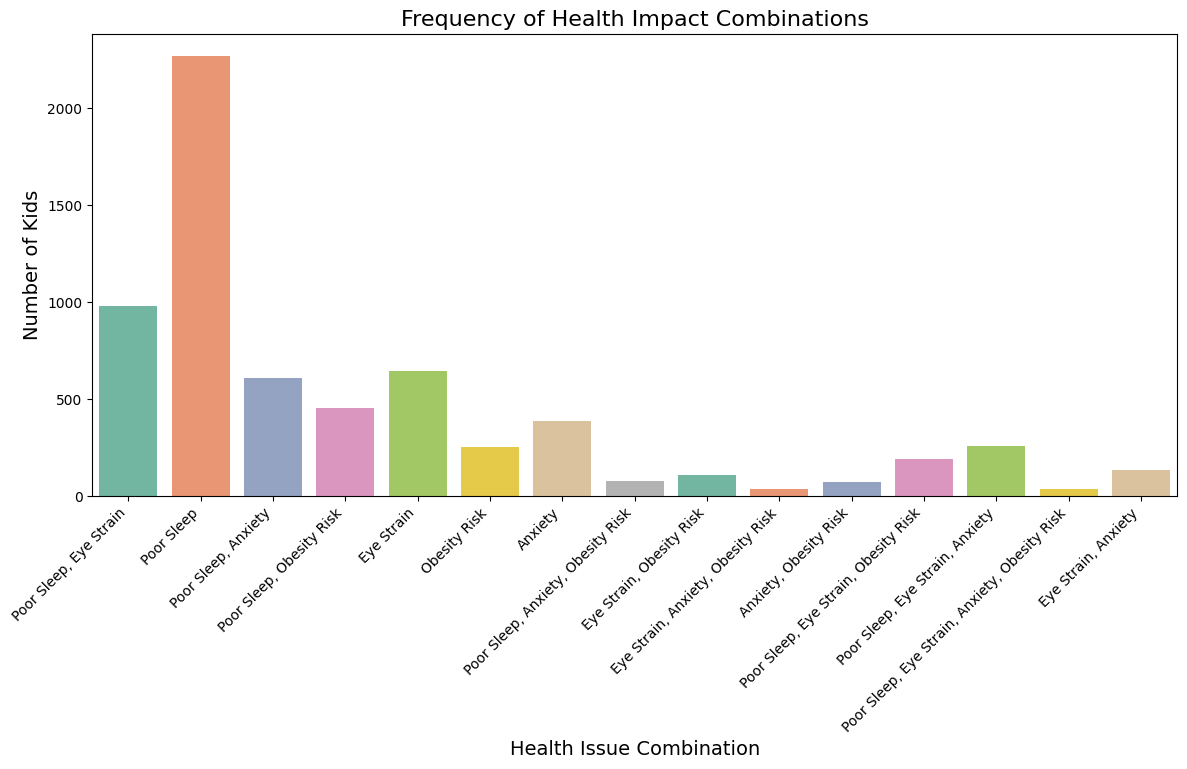

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Indian_Kids_Screen_Time.csv")

plt.figure(figsize=(14,6))
sns.countplot(x='Health_Impacts', data=df, hue='Health_Impacts', legend=False, palette='Set2')

plt.title("Frequency of Health Impact Combinations", fontsize=16)
plt.xlabel("Health Issue Combination", fontsize=14)
plt.ylabel("Number of Kids", fontsize=14)
plt.xticks(rotation=45, ha='right')

plt.show()


**Bivariate analysis**

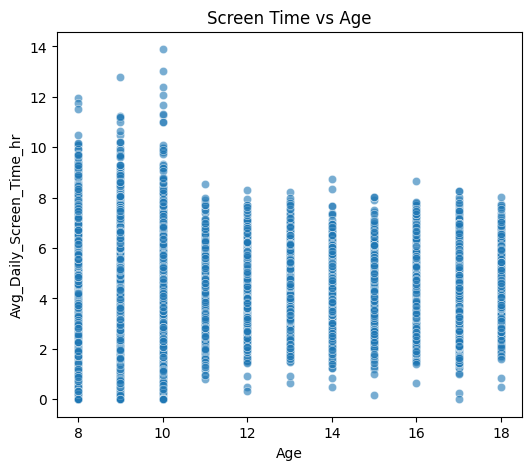

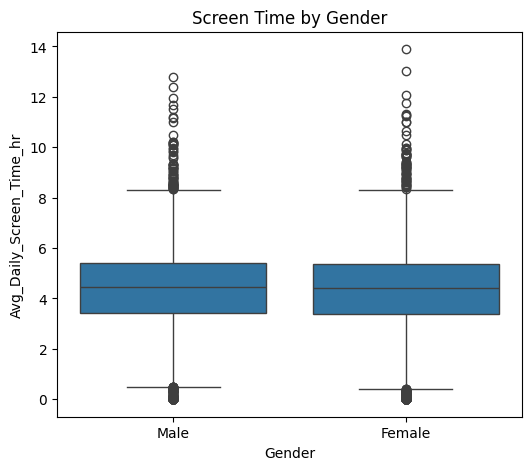

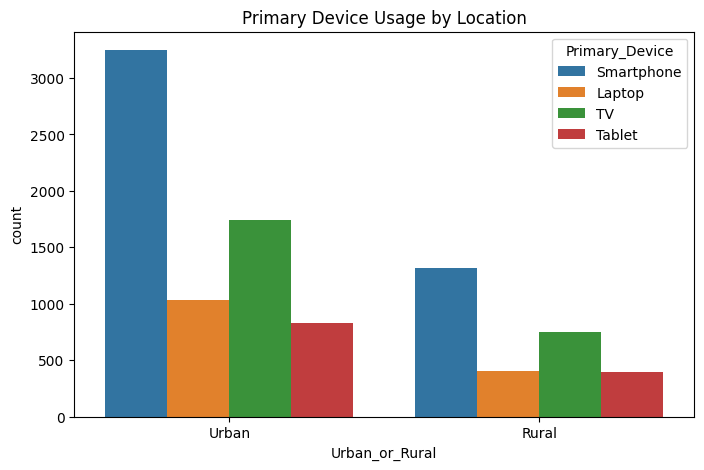

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Indian_Kids_Screen_Time.csv")

plt.figure(figsize=(6,5))
sns.scatterplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df, alpha=0.6)
plt.title("Screen Time vs Age")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Gender")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Urban_or_Rural', hue='Primary_Device', data=df)
plt.title("Primary Device Usage by Location")
plt.show()


 Key Insights

- **Device type:** Smartphones dominate as the primary device, especially in urban areas. Tablets and TVs are more common among younger children.  
- **Age vs Screen Time:** Screen time rises steadily with age, peaking in the 11–15 group. Weekly averages often exceed 20–30 hours.  
- **Exceeded Limits:** A large share of kids surpass the recommended daily limit (>2 hrs/day), with the 8–12 age group being the highest-risk segment.  
- **Education vs Recreation:** Recreational use accounts for the majority of screen time (≈85–90%), with only a minority maintaining balanced educational use.  
- **Health Impacts:** Eye strain, sleep disturbance, and reduced physical activity are the most reported issues. Severity is higher among heavy users.  
- **Gender:** No meaningful differences in screen time patterns between boys and girls.  
- **Urban vs Rural:** Urban children show slightly higher screen time averages, but overall differences between urban and rural are minimal.  
- **Correlation:** Age and screen time are positively correlated, while higher screen time is linked to lower educational/recreational balance.  


**WEEK-2**

In [16]:
import pandas as pd
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB
None


In [17]:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0,5,12,17],
                         labels=['Toddler','Child','Teen'])

In [18]:
df['Screen_Time_Category'] = pd.cut(df['Avg_Daily_Screen_Time_hr'],
                                    bins=[0,2,4,6,24],
                                    labels=['Low','Moderate','High','Very High'])

In [19]:
df['Device_Type_Category'] = df['Primary_Device'].replace({
    'Smartphone':'Mobile/Tablet',
    'Tablet':'Mobile/Tablet',
    'Laptop':'Laptop/PC',
    'Desktop':'Laptop/PC',
    'Television':'TV',
    'Gaming Console':'Gaming'
})

In [20]:
df['Urban_Rural_Score'] = df['Urban_or_Rural'].map({'Urban':1, 'Rural':0})

In [21]:
def st_status(x):
    if x <= 2:
        return 'Healthy'
    elif x <= 4:
        return 'Moderate'
    else:
        return 'Excessive'

df['Screen_Time_Status'] = df['Avg_Daily_Screen_Time_hr'].apply(st_status)

In [22]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Group,Screen_Time_Category,Device_Type_Category,Urban_Rural_Score,Screen_Time_Status
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen,Moderate,Mobile/Tablet,1,Moderate
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Child,High,Laptop/PC,1,Excessive
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,NaN,Moderate,TV,1,Moderate
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,Teen,Low,Laptop/PC,1,Healthy
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child,High,Mobile/Tablet,1,Excessive


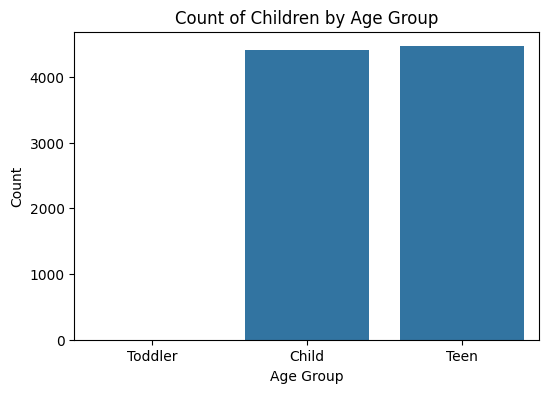

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Age_Group')
plt.title("Count of Children by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

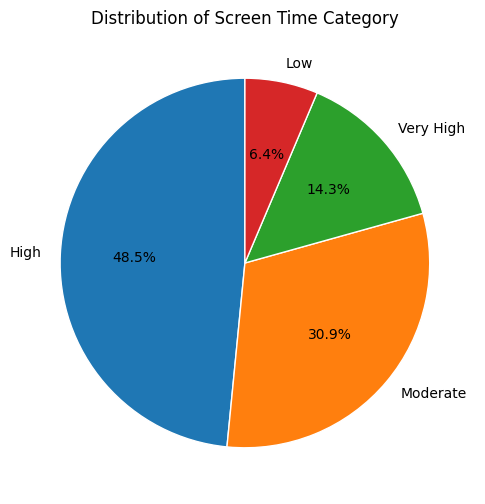

In [24]:
plt.figure(figsize=(6,6))
df['Screen_Time_Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
plt.title("Distribution of Screen Time Category")
plt.ylabel("")
plt.show()

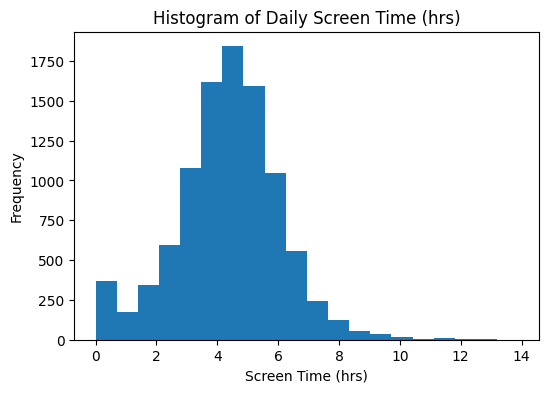

In [25]:
plt.figure(figsize=(6,4))
plt.hist(df['Avg_Daily_Screen_Time_hr'], bins=20)
plt.title("Histogram of Daily Screen Time (hrs)")
plt.xlabel("Screen Time (hrs)")
plt.ylabel("Frequency")
plt.show()

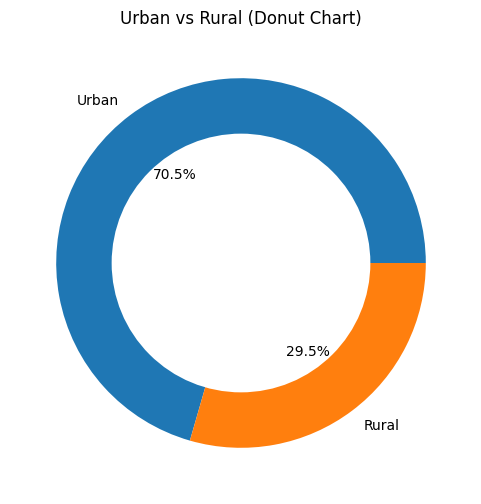

In [26]:
plt.figure(figsize=(6,6))
sizes = df['Urban_or_Rural'].value_counts()
plt.pie(sizes, labels=sizes.index, autopct='%1.1f%%')
center = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center)
plt.title("Urban vs Rural (Donut Chart)")
plt.show()

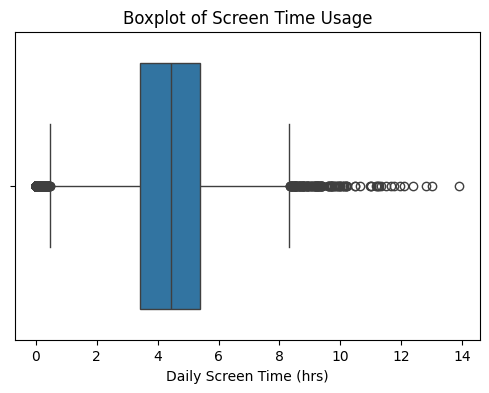

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Avg_Daily_Screen_Time_hr'])
plt.title("Boxplot of Screen Time Usage")
plt.xlabel("Daily Screen Time (hrs)")
plt.show()

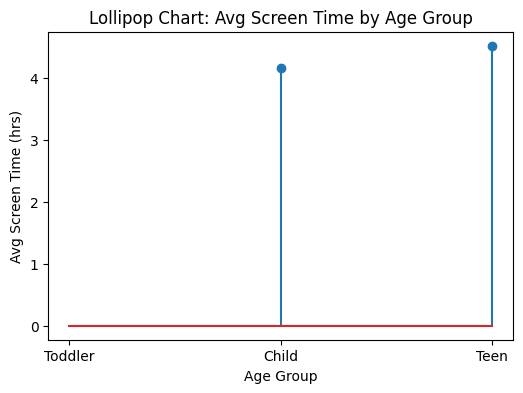

In [28]:
group_mean = df.groupby('Age_Group', observed=False)['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,4))
plt.stem(group_mean.index, group_mean.values)
plt.title("Lollipop Chart: Avg Screen Time by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Avg Screen Time (hrs)")
plt.show()

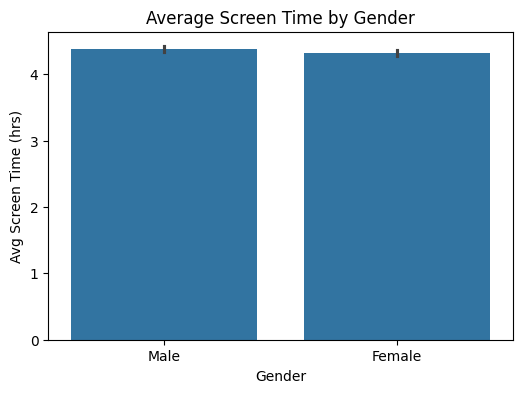

In [29]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Gender', y='Avg_Daily_Screen_Time_hr')
plt.title("Average Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Avg Screen Time (hrs)")
plt.show()

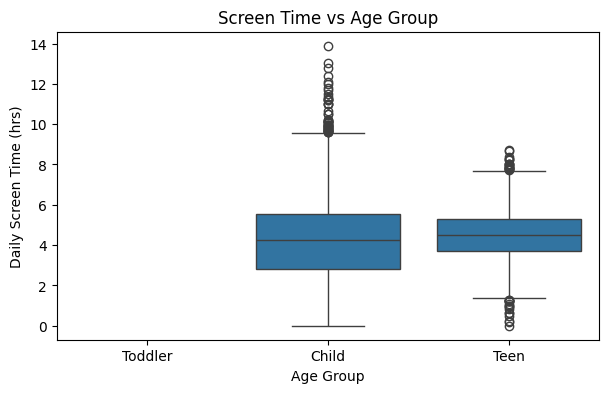

In [30]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Age_Group', y='Avg_Daily_Screen_Time_hr')
plt.title("Screen Time vs Age Group")
plt.xlabel("Age Group")
plt.ylabel("Daily Screen Time (hrs)")
plt.show()

/tmp/ipykernel_5445/36143371.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_values = df.groupby('Age_Group')['Avg_Daily_Screen_Time_hr'].median()


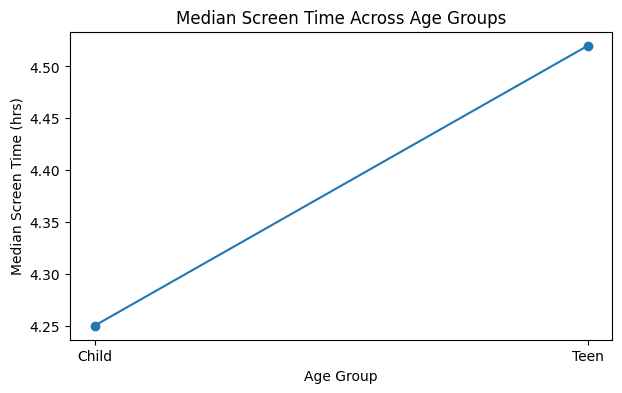

In [31]:
median_values = df.groupby('Age_Group')['Avg_Daily_Screen_Time_hr'].median()

plt.figure(figsize=(7,4))
plt.plot(median_values.index, median_values.values, marker='o')
plt.title("Median Screen Time Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Median Screen Time (hrs)")
plt.show()

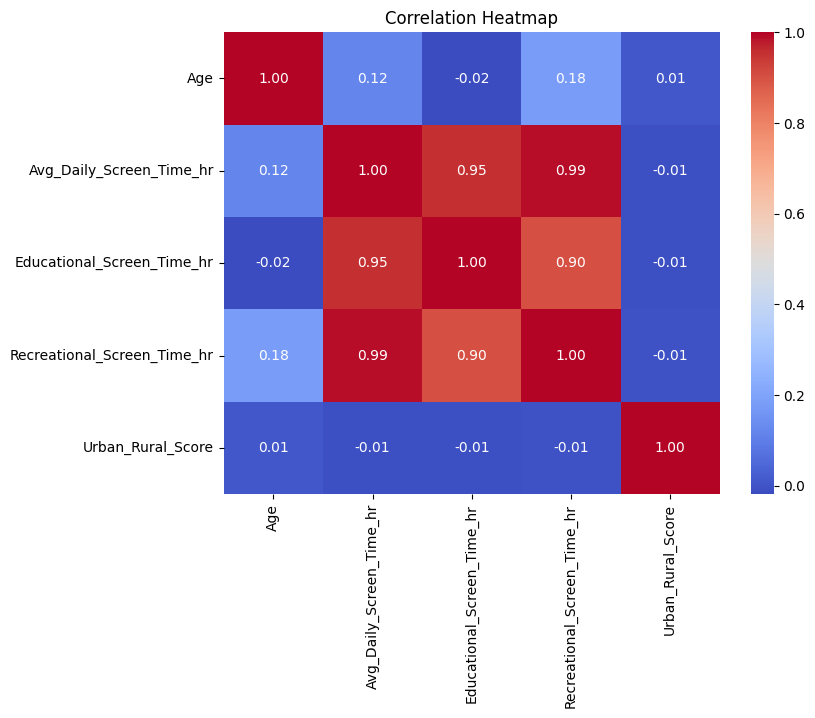

In [32]:
df['Educational_Screen_Time_hr'] = df['Avg_Daily_Screen_Time_hr'] * (df['Educational_to_Recreational_Ratio'] / (1 + df['Educational_to_Recreational_Ratio']))
df['Recreational_Screen_Time_hr'] = df['Avg_Daily_Screen_Time_hr'] - df['Educational_Screen_Time_hr']

plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Age','Avg_Daily_Screen_Time_hr','Educational_Screen_Time_hr',
        'Recreational_Screen_Time_hr','Urban_Rural_Score']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

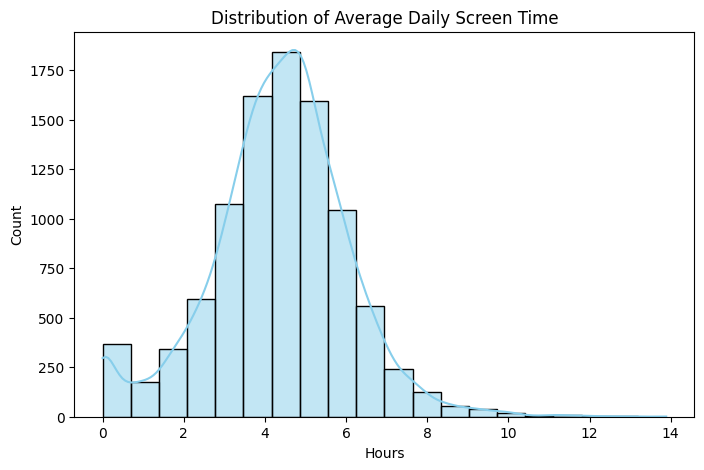

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(
    df['Avg_Daily_Screen_Time_hr'],
    bins=20,
    kde=True,
    color='skyblue'
)
plt.title("Distribution of Average Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

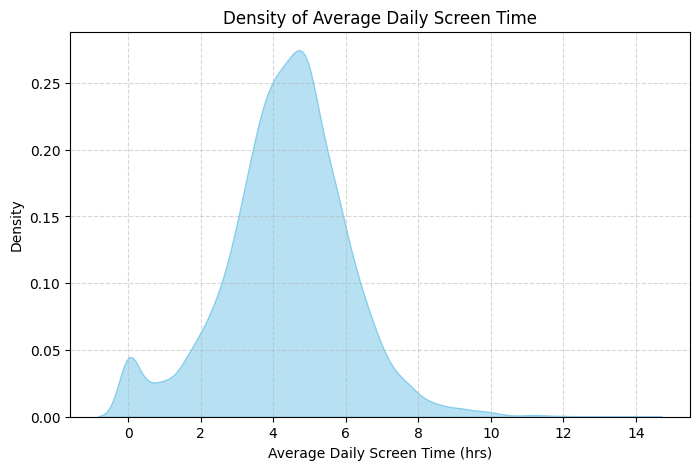

In [34]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x='Avg_Daily_Screen_Time_hr',
    fill=True,
    color='skyblue',
    alpha=0.6
)
plt.title("Density of Average Daily Screen Time")
plt.xlabel("Average Daily Screen Time (hrs)")
plt.ylabel("Density")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

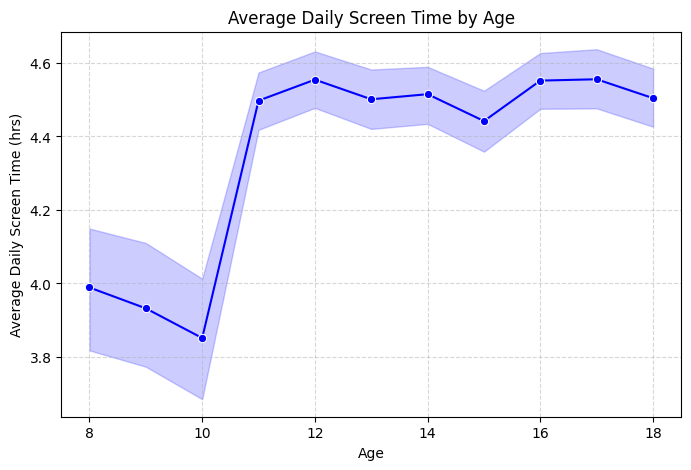

In [35]:
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df,
    x='Age',
    y='Avg_Daily_Screen_Time_hr',
    marker='o',
    color='blue'
)
plt.title("Average Daily Screen Time by Age")
plt.xlabel("Age")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Key Insights**

Device Type: Smartphones dominate as the primary device, especially in urban areas. Tablets and TVs are more common among younger children, while laptops/PCs are used more by older kids.

Age vs Screen Time: Screen time rises steadily with age, peaking in the teen group. Weekly averages often exceed 20–30 hours, showing a clear upward trend.

Exceeded Limits: A large share of children surpass the recommended daily limit (>2 hrs/day). The 8–12 age group emerges as the highest‑risk segment for excessive use.

Education vs Recreation: Recreational use accounts for the majority of screen time (≈85–90%). Only a minority maintain a balanced ratio with educational use.

Health Impacts: Heavy users report issues like eye strain, sleep disturbance, and reduced physical activity. Severity is notably higher among those with excessive screen time.

Gender: No meaningful differences in screen time patterns between boys and girls; usage levels are broadly similar.

Urban vs Rural: Urban children show slightly higher averages, but overall differences between urban and rural groups are minimal.

Correlation: Age and screen time are positively correlated. Higher screen time is linked to a lower educational/recreational balance, reinforcing the dominance of recreational use.

**WEEK-3,4**

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
print(df.head())
print(df.info())
print(df.describe())


   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN          Urban  
4     Poor Sleep, Anx

In [38]:
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")


In [40]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())


['age', 'gender', 'avg_daily_screen_time_hr', 'primary_device', 'exceeded_recommended_limit', 'educational_to_recreational_ratio', 'health_impacts', 'urban_or_rural']


In [41]:
if 'age' in df.columns:
    def age_band(age):
        if age <= 5: return "Toddler"
        elif age <= 10: return "Child"
        elif age <= 15: return "Pre-Teen"
        else: return "Teen"
    df['age_band'] = df['age'].apply(age_band)

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['weekend_flag'] = df['date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
    df['day_of_week'] = df['date'].dt.day_name()


In [42]:
if {'child_id','date','screen_time_hours'}.issubset(df.columns):
    df['device_share'] = df.groupby(['child_id','date'])['screen_time_hours'].transform(lambda x: x / x.sum())
    df['activity_share'] = df.groupby(['child_id','date'])['screen_time_hours'].transform(lambda x: x / x.sum())


In [101]:
df.to_csv("Indian_Kids_Screen_Time_Cleaned.csv", index=False)

with open("Preprocessing_Summary.txt", "w") as f:
    f.write("Preprocessing Summary:\n")
    f.write("- Missing numeric values filled with median.\n")
    f.write("- Missing categorical values filled with mode or 'Unknown'.\n")
    f.write("- Device and Activity categories normalized if present.\n")
    f.write("- Age bands created if Age column exists.\n")
    f.write("- Weekend flag derived from Date if present.\n")
    f.write("- Device and Activity shares calculated if Child_ID, Date, and Screen_Time_Hours exist.\n")
    f.write("- Dates formatted to ISO 8601 if present.\n")

print(" Preprocessing complete. Cleaned dataset and summary saved.")


 Preprocessing complete. Cleaned dataset and summary saved.


In [44]:
import pandas as pd
df_cleaned = pd.read_csv("Indian_Kids_Screen_Time_Cleaned.csv")


In [45]:
print(df_cleaned.head())

   age  gender  avg_daily_screen_time_hr primary_device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   exceeded_recommended_limit  educational_to_recreational_ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           health_impacts urban_or_rural  age_band  
0  Poor Sleep, Eye Strain          Urban  Pre-Teen  
1              Poor Sleep          Urban  Pre-Teen  
2              Poor Sleep          Urban      Teen  
3              Poor Slee

**univariate analysis**

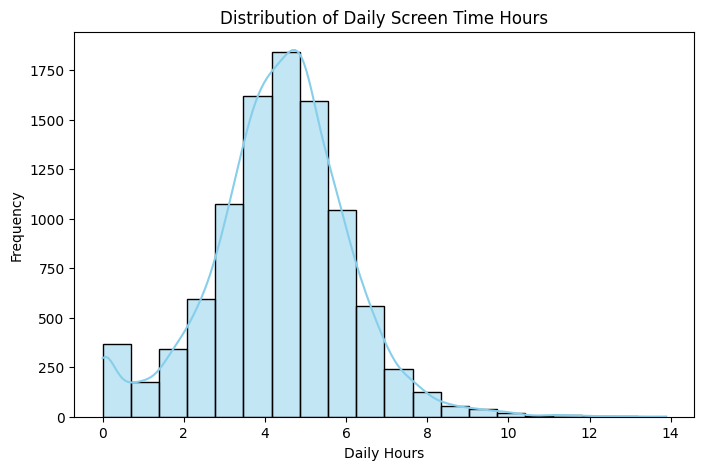

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(df['avg_daily_screen_time_hr'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Daily Screen Time Hours")
plt.xlabel("Daily Hours")
plt.ylabel("Frequency")
plt.show()

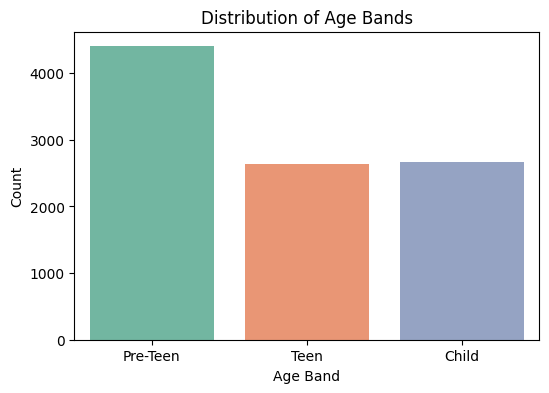

In [47]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='age_band',
    hue='age_band',
    data=df,
    palette='Set2',
    legend=False
)
plt.title("Distribution of Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()


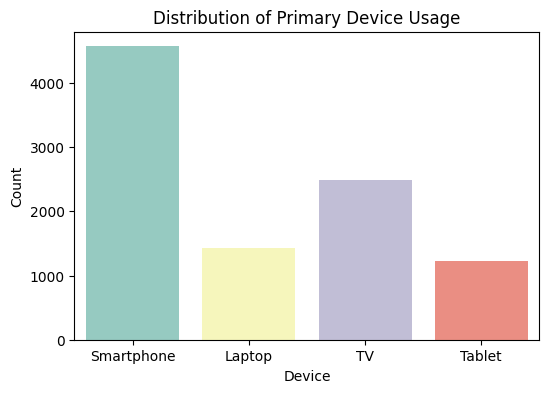

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='primary_device',
    hue='primary_device',
    data=df,
    palette='Set3',
    legend=False
)
plt.title("Distribution of Primary Device Usage")
plt.xlabel("Device")
plt.ylabel("Count")
plt.show()


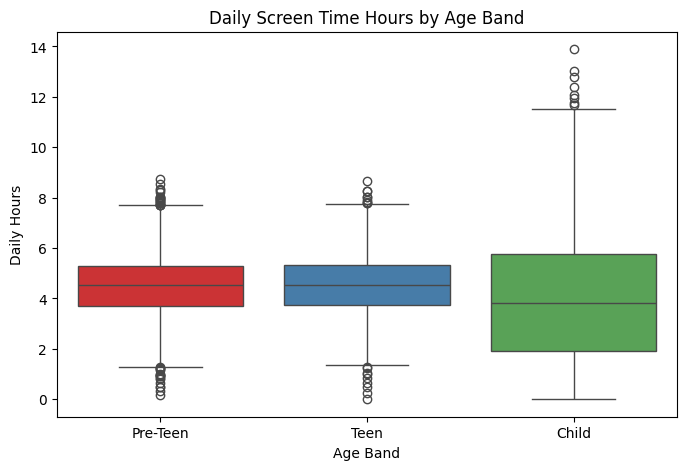

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='age_band',
    y='avg_daily_screen_time_hr',
    hue='age_band',
    data=df,
    palette='Set1',
    legend=False
)
plt.title("Daily Screen Time Hours by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Daily Hours")
plt.show()


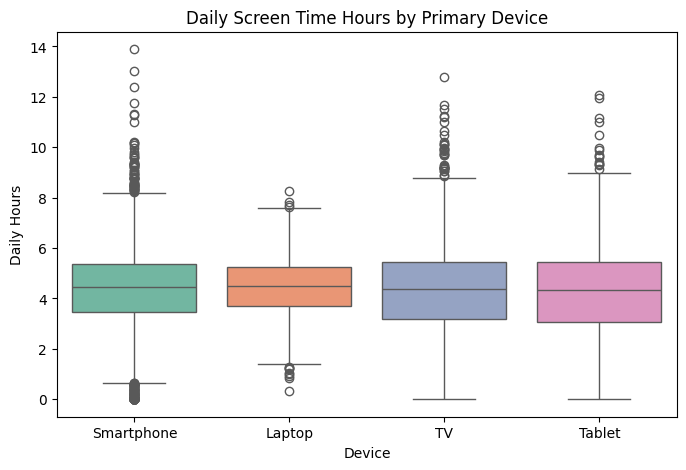

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='primary_device',
    y='avg_daily_screen_time_hr',
    hue='primary_device',
    data=df,
    palette='Set2',
    legend=False
)
plt.title("Daily Screen Time Hours by Primary Device")
plt.xlabel("Device")
plt.ylabel("Daily Hours")
plt.show()


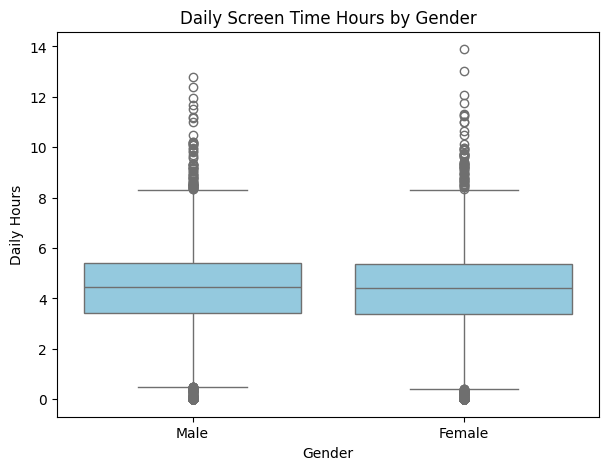

In [51]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x='gender',
    y='avg_daily_screen_time_hr',
    data=df,
    color='skyblue'
)
plt.title("Daily Screen Time Hours by Gender")
plt.xlabel("Gender")
plt.ylabel("Daily Hours")
plt.show()


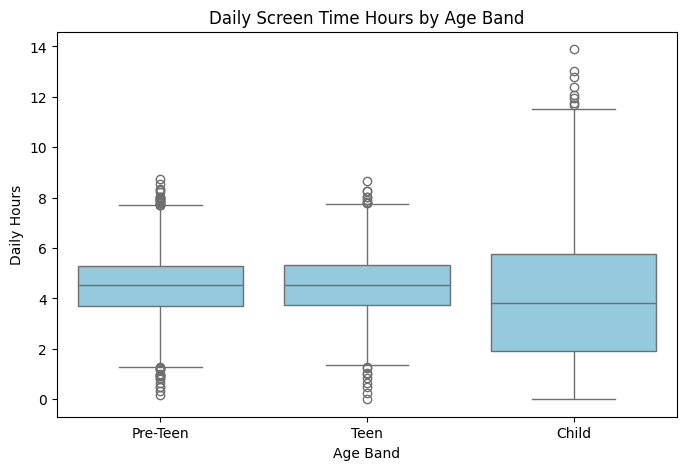

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='age_band',
    y='avg_daily_screen_time_hr',
    data=df,
    color='skyblue'
)
plt.title("Daily Screen Time Hours by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Daily Hours")
plt.show()


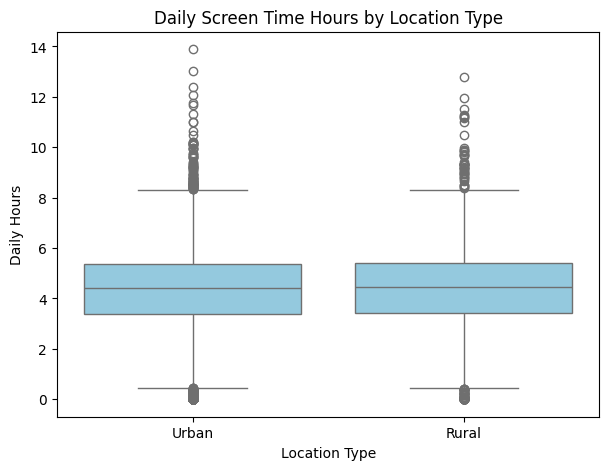

In [53]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x='urban_or_rural',
    y='avg_daily_screen_time_hr',
    data=df,
    color='skyblue'
)
plt.title("Daily Screen Time Hours by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Daily Hours")
plt.show()


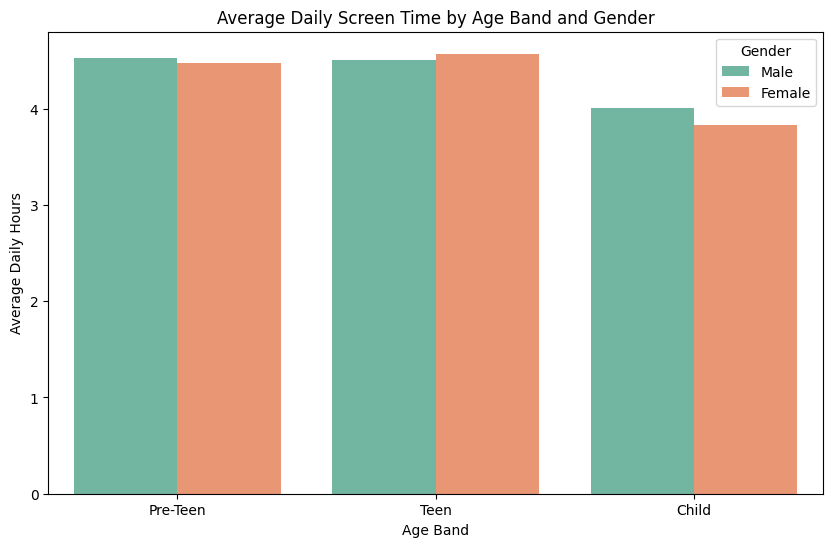

In [54]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='age_band',
    y='avg_daily_screen_time_hr',
    hue='gender',
    data=df,
    errorbar=None,
    palette='Set2'
)
plt.title("Average Daily Screen Time by Age Band and Gender")
plt.xlabel("Age Band")
plt.ylabel("Average Daily Hours")
plt.legend(title="Gender")
plt.show()

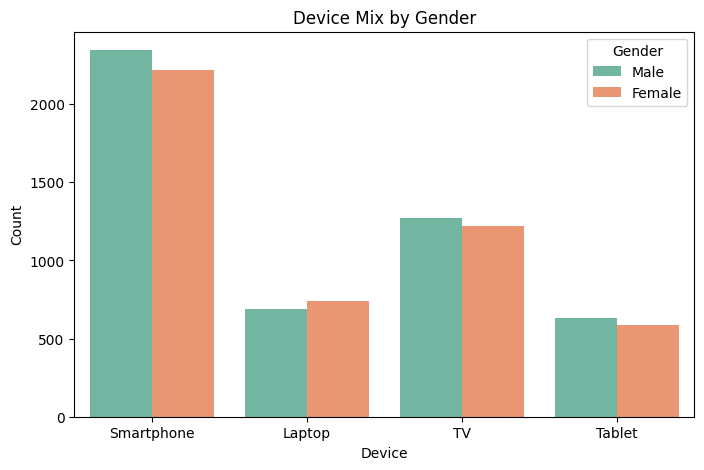

In [55]:
plt.figure(figsize=(8,5))
sns.countplot(x='primary_device', hue='gender', data=df, palette='Set2')
plt.title("Device Mix by Gender")
plt.xlabel("Device")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.show()

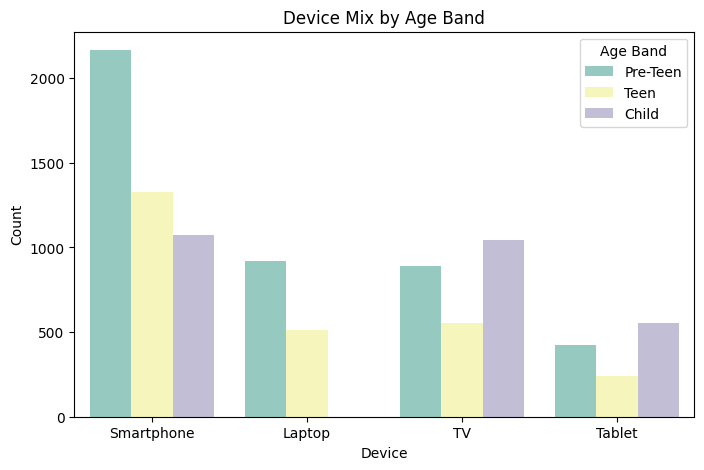

In [56]:
plt.figure(figsize=(8,5))
sns.countplot(x='primary_device', hue='age_band', data=df, palette='Set3')
plt.title("Device Mix by Age Band")
plt.xlabel("Device")
plt.ylabel("Count")
plt.legend(title="Age Band")
plt.show()

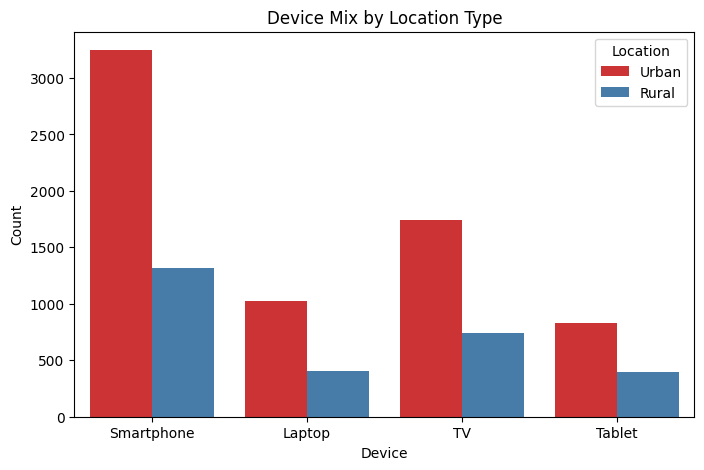

In [57]:
plt.figure(figsize=(8,5))
sns.countplot(x='primary_device', hue='urban_or_rural', data=df, palette='Set1')
plt.title("Device Mix by Location Type")
plt.xlabel("Device")
plt.ylabel("Count")
plt.legend(title="Location")
plt.show()


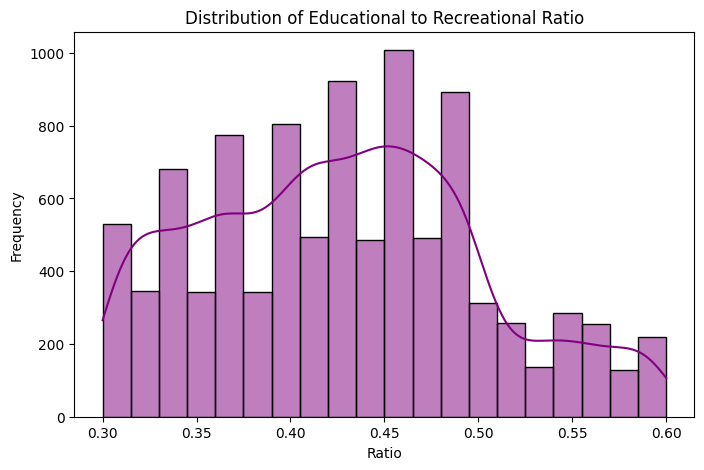

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(df['educational_to_recreational_ratio'], bins=20, kde=True, color='purple')
plt.title("Distribution of Educational to Recreational Ratio")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()

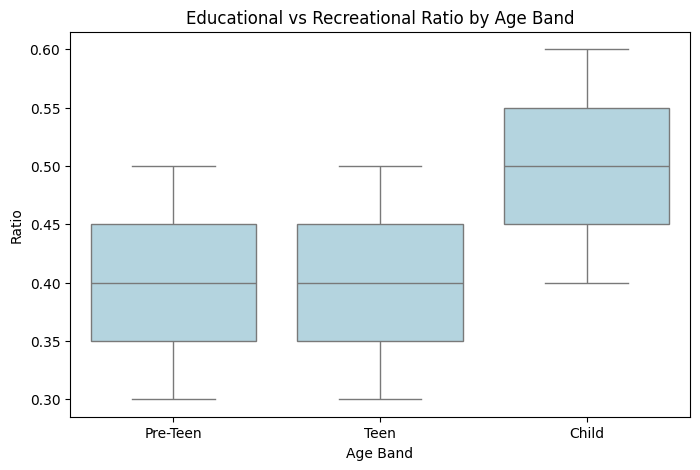

In [59]:
plt.figure(figsize=(8,5))
sns.boxplot(x='age_band', y='educational_to_recreational_ratio', data=df, color='lightblue')
plt.title("Educational vs Recreational Ratio by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Ratio")
plt.show()


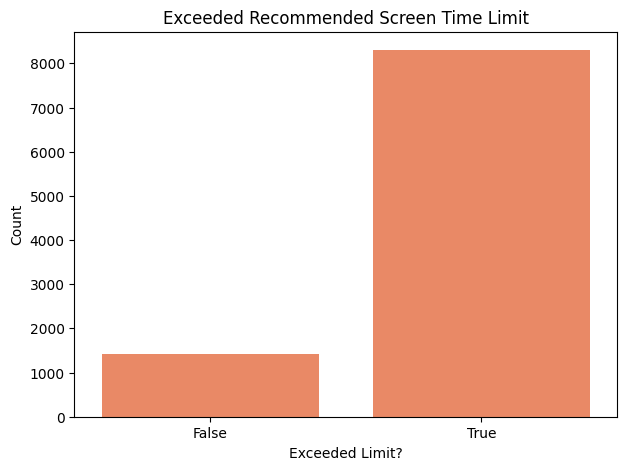

In [60]:
plt.figure(figsize=(7,5))
sns.countplot(x='exceeded_recommended_limit', data=df, color='coral')
plt.title("Exceeded Recommended Screen Time Limit")
plt.xlabel("Exceeded Limit?")
plt.ylabel("Count")
plt.show()


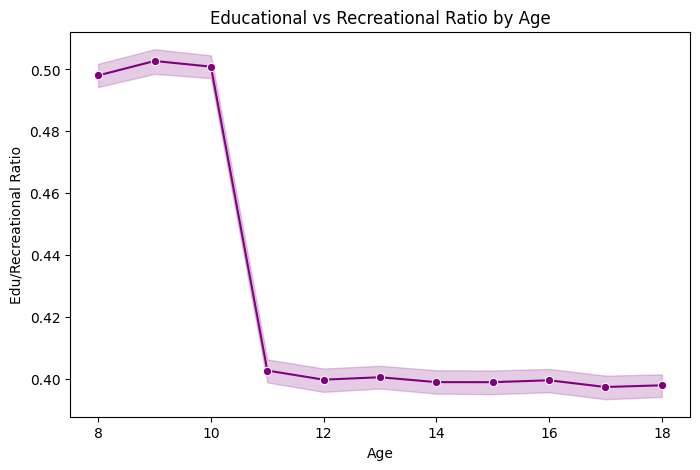

In [61]:
plt.figure(figsize=(8,5))
sns.lineplot(x='age', y='educational_to_recreational_ratio', data=df, marker='o', color='purple')
plt.title("Educational vs Recreational Ratio by Age")
plt.xlabel("Age")
plt.ylabel("Edu/Recreational Ratio")
plt.show()


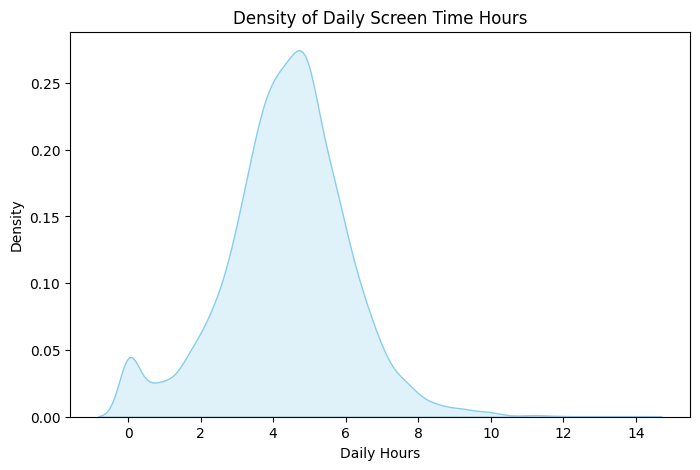

In [62]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['avg_daily_screen_time_hr'], fill=True, color='skyblue')
plt.title("Density of Daily Screen Time Hours")
plt.xlabel("Daily Hours")
plt.ylabel("Density")
plt.show()

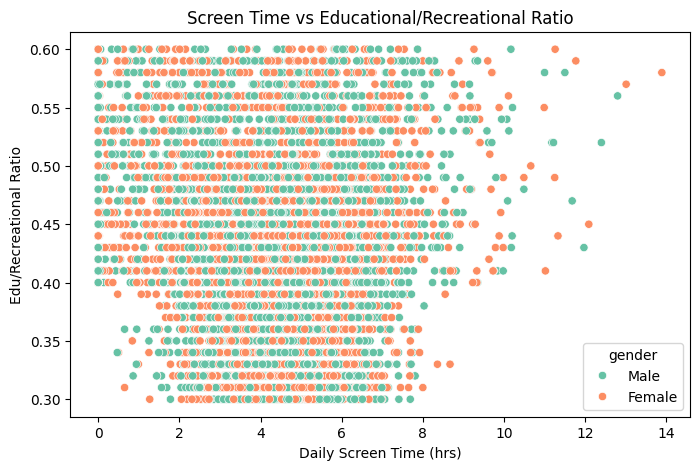

In [63]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='avg_daily_screen_time_hr', y='educational_to_recreational_ratio', hue='gender', data=df, palette='Set2')
plt.title("Screen Time vs Educational/Recreational Ratio")
plt.xlabel("Daily Screen Time (hrs)")
plt.ylabel("Edu/Recreational Ratio")
plt.show()


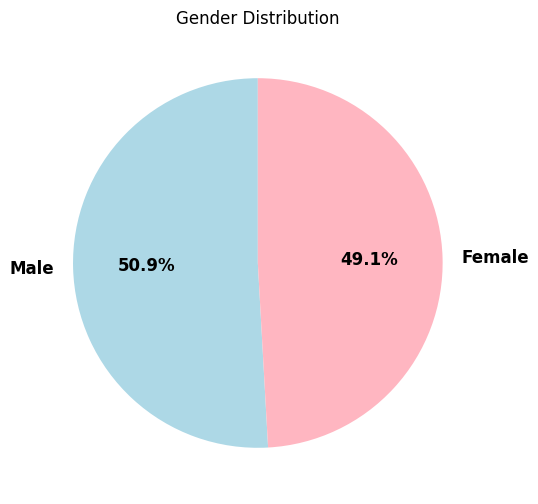

In [64]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightblue','lightpink'],
    textprops={'fontsize':12, 'weight':'bold'}
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_weight('bold')

plt.title("Gender Distribution")
plt.show()


**Key Insights**



Device Type: Smartphones are the most common primary device across children. Tablets and TVs appear more among younger kids, while laptops/PCs are more frequent among older ones. Device mix varies slightly by gender and location, but smartphones dominate everywhere.

Age vs Screen Time: Screen time increases steadily with age, peaking in the Pre‑Teen (11–15) group. Boxplots show higher daily averages and more variability in older age bands.

Exceeded Limits: A large proportion of children exceed the recommended daily limit (>2 hrs/day). The 8–12 age group is the most at risk for excessive use.

Education vs Recreation: Recreational use strongly outweighs educational use (≈85–90%). The educational/recreational ratio declines with age, showing that older children spend proportionally less time on educational activities.

Gender: No meaningful differences in screen time patterns between boys and girls. Both genders show similar averages and device preferences.

Urban vs Rural: Urban children show slightly higher screen time averages, but overall differences between urban and rural groups are minimal. Device mix is similar across both.

Correlation: Age and screen time are positively correlated. Higher screen time is linked to a lower educational/recreational balance, reinforcing the dominance of recreational use.

Density & Scatter Patterns: Most children cluster around 3–5 hours daily, with a long tail of heavy users. Scatterplots confirm that as screen time rises, the educational/recreational ratio drops.

**WEEK-5**

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [67]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [69]:
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,3218
Urban_or_Rural,0


In [70]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [71]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [72]:
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0


In [73]:
bins = [5,10,13,16,19]
labels = ["6-10","11-13","14-16","17-18"]
df["Age_Band"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [74]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-16
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,11-13
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,17-18
3,15,Female,1.21,Laptop,False,0.39,Poor Sleep,Urban,14-16
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,11-13


In [75]:
cohort_table = pd.pivot_table(
    df,
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Primary_Device",
    aggfunc="mean"
)

cohort_table

/tmp/ipykernel_5445/541133036.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cohort_table = pd.pivot_table(


Primary_Device,Laptop,Smartphone,TV,Tablet
Age_Band,,,,
6-10,NaN,3.921901,3.932201,3.917680
11-13,4.432627,4.537596,4.573583,4.478175
14-16,4.428815,4.521197,4.563499,4.438520
17-18,4.549853,4.540847,4.477568,4.555843


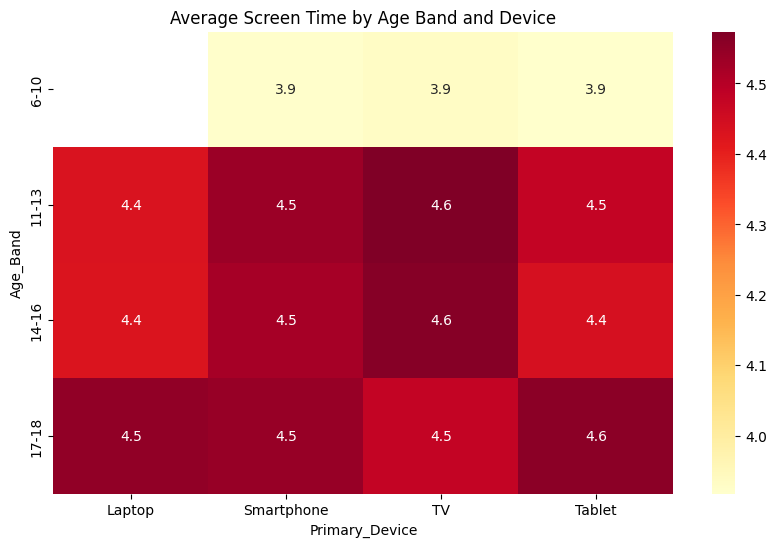

In [76]:
plt.figure(figsize=(10,6))

sns.heatmap(cohort_table,
            annot=True,
            cmap="YlOrRd")

plt.title("Average Screen Time by Age Band and Device")
plt.show()

In [77]:
location_device = pd.pivot_table(
    df,
    values="Avg_Daily_Screen_Time_hr",
    index="Urban_or_Rural",
    columns="Primary_Device",
    aggfunc="mean"
)

location_device

Primary_Device,Laptop,Smartphone,TV,Tablet
Urban_or_Rural,,,,
Rural,4.387252,4.397295,4.293812,4.432117
Urban,4.487289,4.385523,4.285161,4.128894


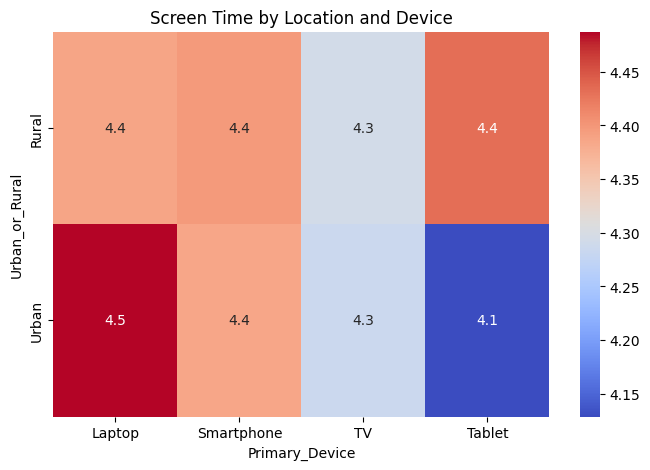

In [78]:
plt.figure(figsize=(8,5))

sns.heatmap(location_device,
            annot=True,
            cmap="coolwarm")

plt.title("Screen Time by Location and Device")
plt.show()

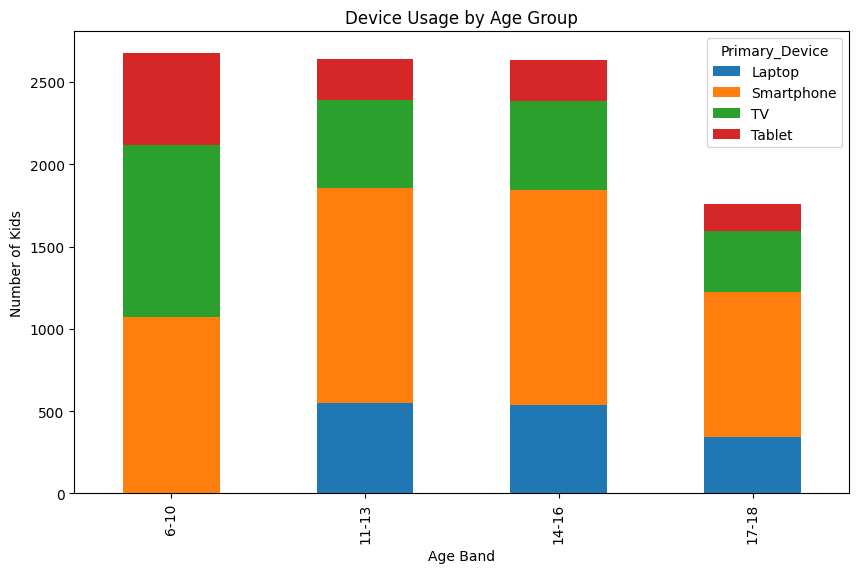

In [79]:
device_age = pd.crosstab(df["Age_Band"], df["Primary_Device"])

device_age.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Device Usage by Age Group")
plt.xlabel("Age Band")
plt.ylabel("Number of Kids")
plt.show()

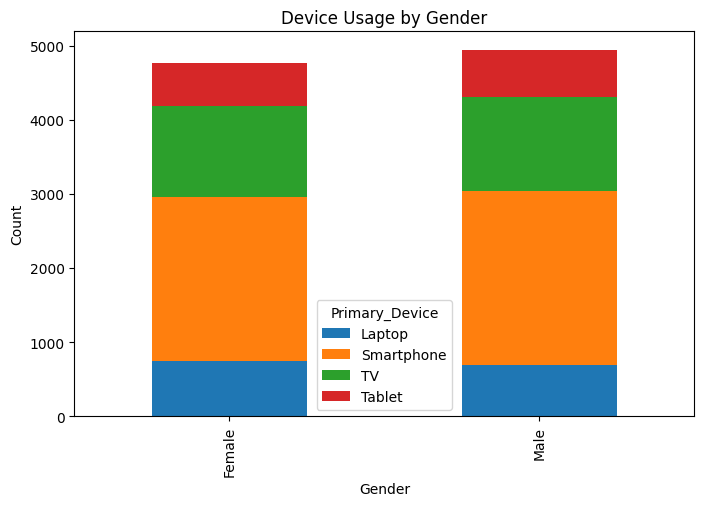

In [80]:
gender_device = pd.crosstab(df["Gender"], df["Primary_Device"])

gender_device.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Device Usage by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [81]:
age_location = pd.pivot_table(
    df,
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Urban_or_Rural",
    aggfunc="mean"
)

age_location

/tmp/ipykernel_5445/3289003229.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_location = pd.pivot_table(


Urban_or_Rural,Rural,Urban
Age_Band,,
6-10,3.990426,3.897189
11-13,4.533568,4.510757
14-16,4.511708,4.499360
17-18,4.522080,4.534321


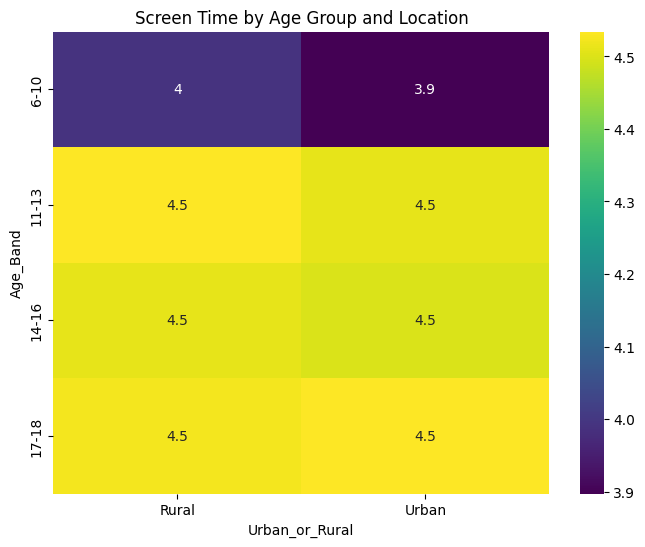

In [82]:
plt.figure(figsize=(8,6))

sns.heatmap(age_location,
            annot=True,
            cmap="viridis")

plt.title("Screen Time by Age Group and Location")
plt.show()

**Key Insights**

Smartphones are the dominant device across age, gender, and location.

Age strongly influences device mix: younger kids lean toward tablets/TVs, while older teens shift toward laptops/PCs.

Urban children spend more time on screens overall, but rural children still show significant usage, especially on TVs.

Gender differences are minimal, suggesting similar digital habits across boys and girls.

**WEEK-6**

In [83]:
df["Health_Impacts"] = df["Health_Impacts"].fillna("None")

In [84]:
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0
Age_Band,0


In [85]:
bins = [5,10,13,16,19]
labels = ["6-10","11-13","14-16","17-18"]
df["Age_Band"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [86]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-16
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,11-13
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,17-18
3,15,Female,1.21,Laptop,False,0.39,Poor Sleep,Urban,14-16
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,11-13


In [87]:
age_pattern = df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean()
age_pattern

/tmp/ipykernel_5445/2069780091.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_pattern = df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean()


,Avg_Daily_Screen_Time_hr
Age_Band,
6-10,3.925049
11-13,4.517264
14-16,4.503145
17-18,4.530841


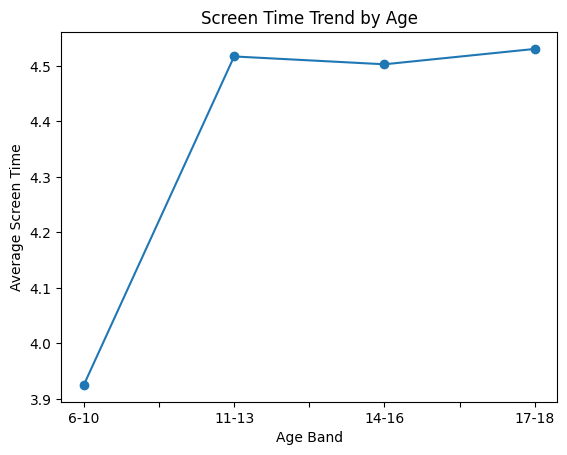

In [88]:
age_pattern.plot(kind="line", marker="o")

plt.title("Screen Time Trend by Age")

plt.xlabel("Age Band")

plt.ylabel("Average Screen Time")

plt.show()

In [89]:
device_pattern = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean()

device_pattern

,Avg_Daily_Screen_Time_hr
Primary_Device,
Laptop,4.459086
Smartphone,4.388925
TV,4.287752
Tablet,4.226005


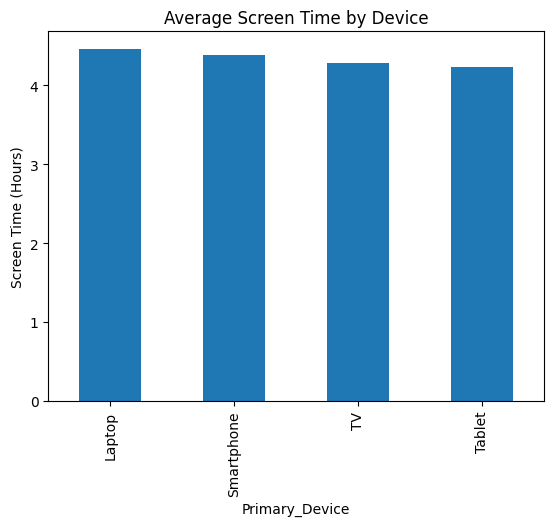

In [90]:
device_pattern.plot(kind="bar")

plt.title("Average Screen Time by Device")

plt.ylabel("Screen Time (Hours)")

plt.show()

In [91]:
gender_pattern = df.groupby("Gender")["Avg_Daily_Screen_Time_hr"].mean()
gender_pattern

,Avg_Daily_Screen_Time_hr
Gender,
Female,4.327021
Male,4.377754


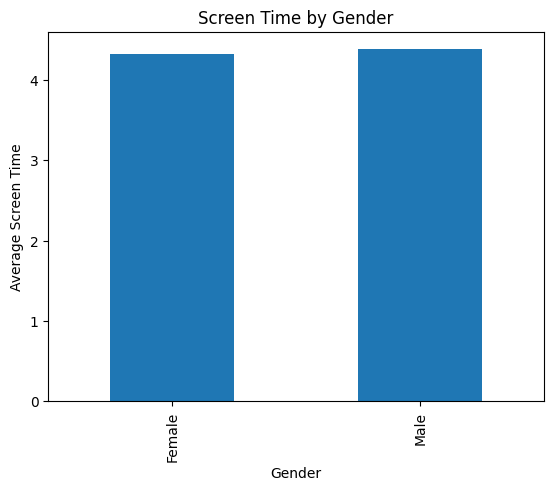

In [92]:
gender_pattern.plot(kind="bar")

plt.title("Screen Time by Gender")

plt.ylabel("Average Screen Time")

plt.show()

In [93]:
location_pattern = df.groupby("Urban_or_Rural")["Avg_Daily_Screen_Time_hr"].mean()

location_pattern

,Avg_Daily_Screen_Time_hr
Urban_or_Rural,
Rural,4.373702
Urban,4.344123


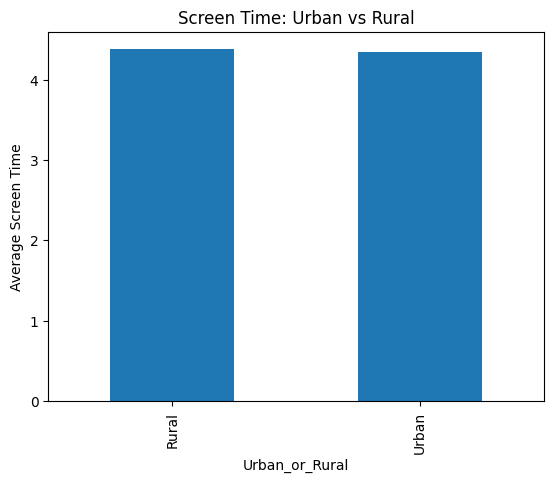

In [94]:
location_pattern.plot(kind="bar")

plt.title("Screen Time: Urban vs Rural")

plt.ylabel("Average Screen Time")

plt.show()

In [95]:
health_pattern = df["Health_Impacts"].value_counts()
health_pattern

,count
Health_Impacts,
Poor Sleep,5486
"Poor Sleep, Eye Strain",979
Eye Strain,644
"Poor Sleep, Anxiety",608
"Poor Sleep, Obesity Risk",452
Anxiety,385
"Poor Sleep, Eye Strain, Anxiety",258
Obesity Risk,252
"Poor Sleep, Eye Strain, Obesity Risk",188


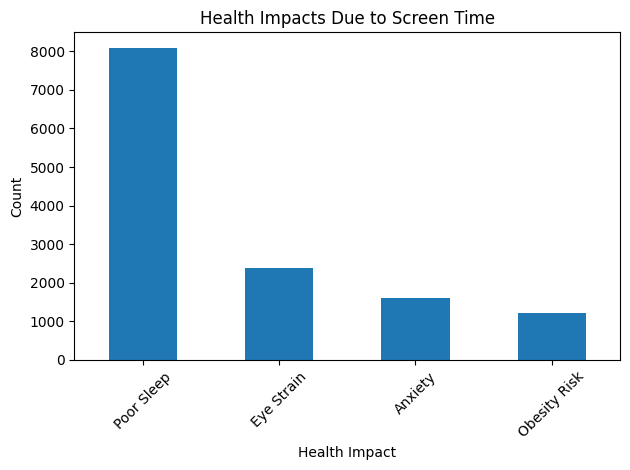

In [96]:

df["Health_Impacts"] = df["Health_Impacts"].astype(str)
health_exploded = df["Health_Impacts"].str.split(", ").explode()

health_counts = health_exploded.value_counts()

# Plot
health_counts.plot(kind="bar")

plt.title("Health Impacts Due to Screen Time")
plt.xlabel("Health Impact")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [100]:
edu_pattern = df.groupby("Age_Band")["Educational_to_Recreational_Ratio"].mean()
edu_pattern

/tmp/ipykernel_5445/742758318.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edu_pattern = df.groupby("Age_Band")["Educational_to_Recreational_Ratio"].mean()


,Educational_to_Recreational_Ratio
Age_Band,
6-10,0.500553
11-13,0.400893
14-16,0.399052
17-18,0.397544


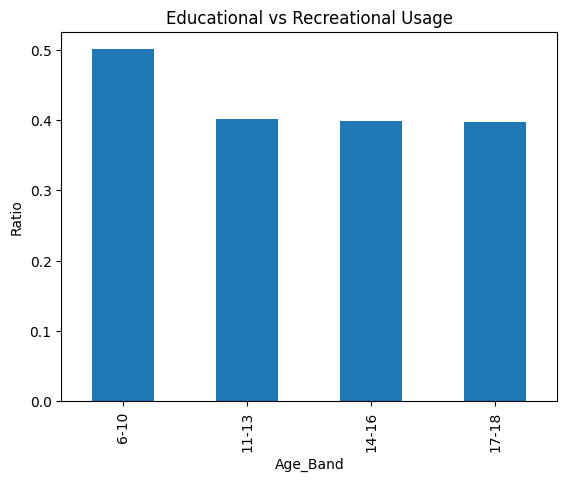

In [98]:
edu_pattern.plot(kind="bar")

plt.title("Educational vs Recreational Usage")

plt.ylabel("Ratio")

plt.show()

/tmp/ipykernel_5445/1473468435.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


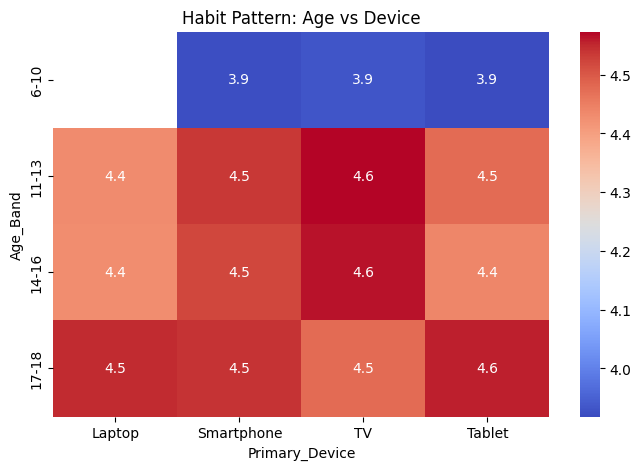

In [99]:
pivot = pd.pivot_table(
    df,
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Primary_Device",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))

sns.heatmap(pivot, annot=True, cmap="coolwarm")

plt.title("Habit Pattern: Age vs Device")

plt.show()

**Key Insights**

Screen time grows with age, peaking in teenage years.

Smartphones are the dominant device, regardless of age, gender, or location.

Recreational use outweighs educational use, especially in older children.

Urban children show slightly higher averages, but rural children are not far behind.

Health impacts are widespread, with eye strain and sleep disturbance being the most common.

Gender differences are negligible, indicating similar digital habits across boys and girls.